In [1]:
# Import required libraries

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Set dataset path

dataset_path = "/content/drive/MyDrive/mnist_png"

train_path = os.path.join(dataset_path, "training")
test_path = os.path.join(dataset_path, "testing")

Load Dataset Function

In [4]:
# Function to load grayscale images

IMG_SIZE = 28

def load_dataset(folder_path):

    images = []

    for digit in sorted(os.listdir(folder_path)):

        digit_path = os.path.join(folder_path, digit)

        if os.path.isdir(digit_path):

            for image_name in os.listdir(digit_path):

                image_path = os.path.join(digit_path, image_name)

                image = load_img(
                    image_path,
                    color_mode="grayscale",
                    target_size=(IMG_SIZE, IMG_SIZE)
                )

                image = img_to_array(image)

                image = image / 255.0

                images.append(image)

    return np.array(images)

Load Training and Testing Images

In [5]:
# Load training and testing images

train_images = load_dataset(train_path)
test_images = load_dataset(test_path)

print("Training Images :", train_images.shape)
print("Testing Images  :", test_images.shape)

Training Images : (60000, 28, 28, 1)
Testing Images  : (10000, 28, 28, 1)


Visualize Original Images

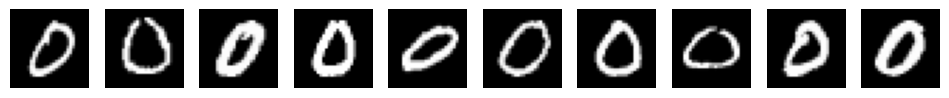

In [6]:
# Display original images

plt.figure(figsize=(12,2))

for i in range(10):

    plt.subplot(1,10,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

Add Gaussian Noise

In [7]:
# Add Gaussian noise

noise_factor = 0.5

x_train_noisy = train_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=train_images.shape
)

x_test_noisy = test_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=test_images.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Display Original vs Noisy Images

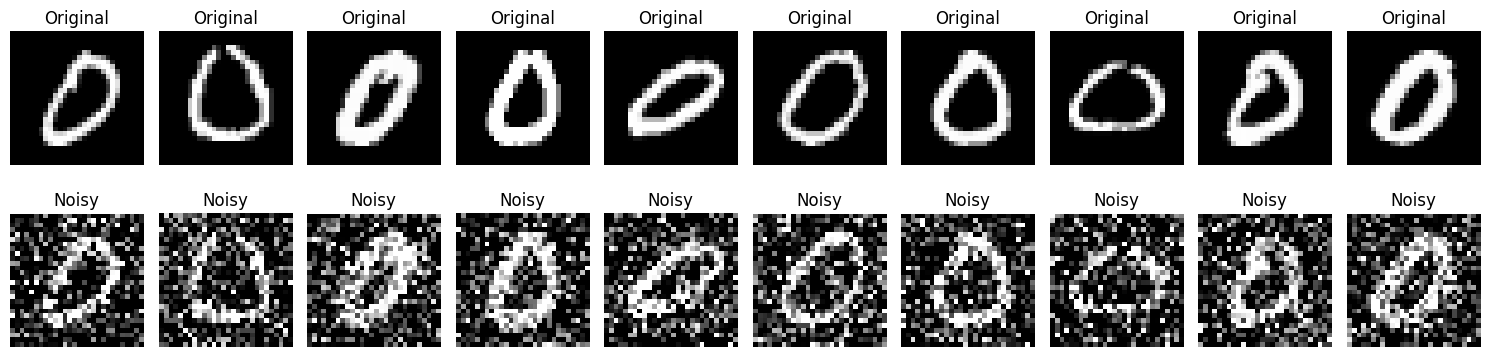

In [8]:
# Compare original and noisy images

plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

plt.tight_layout()
plt.show()

Build Autoencoder

In [9]:
# Build denoising autoencoder

input_image = Input(shape=(28,28,1))

x = Conv2D(32, (3,3), activation="relu", padding="same")(input_image)
x = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

autoencoder = Model(input_image, decoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Train Autoencoder

In [10]:
# Train the model

history = autoencoder.fit(
    x_train_noisy,
    train_images,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, test_images)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.1660 - val_loss: 0.1161
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.1132 - val_loss: 0.1086
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1081 - val_loss: 0.1056
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1055 - val_loss: 0.1033
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1037 - val_loss: 0.1021
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1023 - val_loss: 0.1007
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1012 - val_loss: 0.0998
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1003 - val_loss: 0.0994
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0996 - val_loss: 0.0989
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0990 - val_loss: 0.0984
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0984 - val_loss: 0.0977
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/s

Plot Training History

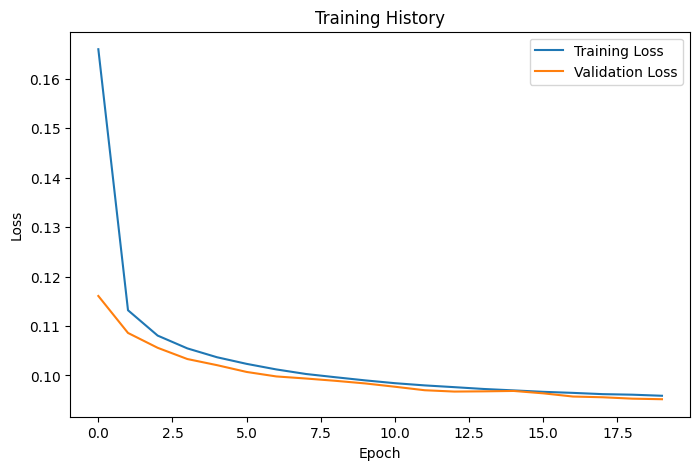

In [11]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")

plt.legend()

plt.show()

Predict Denoised Images

In [12]:
# Predict denoised images

decoded_images = autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Visualize Results

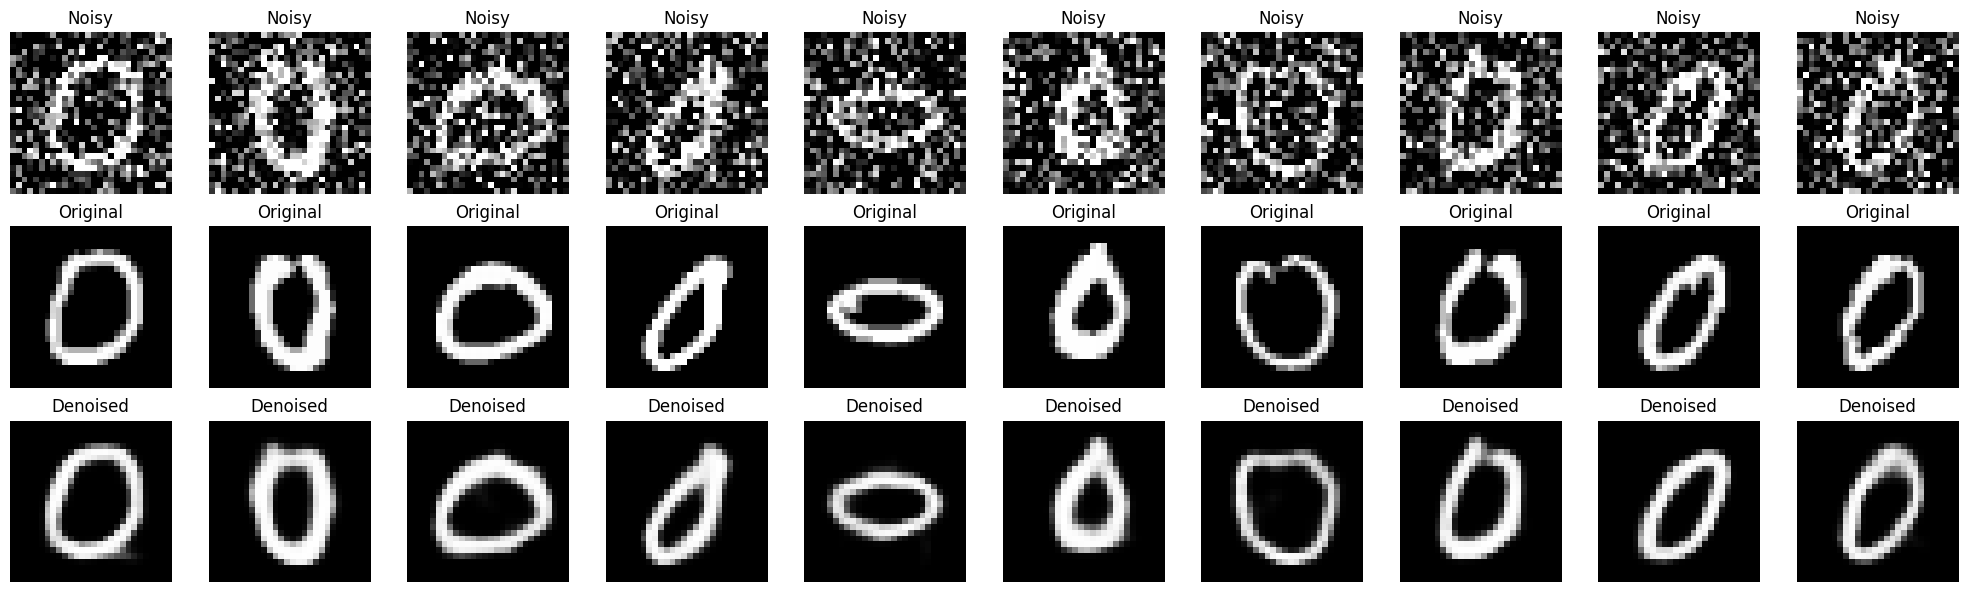

In [13]:
# Display noisy, original and reconstructed images

n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3,n,i+n+1)
    plt.imshow(test_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

Calculate MSE

In [14]:
# Calculate Mean Squared Error

mse = np.mean((decoded_images - test_images) ** 2)

print("Mean Squared Error :", mse)

Mean Squared Error : 0.010764107


Calculate PSNR

In [15]:
# Calculate Peak Signal-to-Noise Ratio

psnr = tf.image.psnr(
    decoded_images,
    test_images,
    max_val=1.0
)

print("Average PSNR :", np.mean(psnr))

Average PSNR : 20.009678


Save Model

In [16]:
# Save trained autoencoder

autoencoder.save("mnist_denoising_autoencoder.h5")

print("Model saved successfully.")

Model saved successfully.
